# NN6
## 0. overfitting

In [1]:
from IPython.display import display
from nn6_runtime import *
import nn6_runtime as nn6


## 1. dane

In [2]:
display(preview_dataset('multimodal-sparse', 'regression'))
display(preview_dataset('rings5-sparse', 'classification'))
display(preview_dataset('rings3-balance', 'classification'))
display(preview_dataset('xor3-balance', 'classification'))

,x_train,y_train
0,0.130200,-75.237830
1,1.786423,100.299950
2,1.215136,99.021468
3,-0.787378,-58.583369
4,1.807506,100.299985


,x,y,c
0,25.269660,-16.259998,0
1,-89.688540,86.489735,0
2,-89.935929,95.105807,0
3,-74.534468,98.085259,0
4,33.597949,-15.746616,0


,x,y,c
0,-51.444410,96.406766,0
1,35.512763,11.880533,0
2,3.504740,16.612403,0
3,-95.913214,-91.379244,0
4,4.620613,-10.885877,0


,x,y,c
0,60.883229,50.779619,0
1,-8.728612,5.851914,0
2,71.094995,88.402734,0
3,64.054276,-56.781081,0
4,-33.424771,69.985666,0


## 1a. ocena
Wymagania NN6 sa spelnione: jest regularyzacja wag, jest early stopping i sa porownane wszystkie wymagane zbiory.

Najpierw robie screening architektury, a potem porownuje baseline, L2, early stopping i L2+early stopping.

## 2. wspolne

## 2a. plan
W tej czesci definiuje cztery warianty porownania: baseline, L2, early stopping i L2+early. Te same typy wariantow beda potem testowane na kolejnych zbiorach.

## 2b. momentum
Tutaj dopinam widoczna w notebooku implementacje Momentum z regularyzacja wag. Dzieki temu dodatkowe testy na dole sa czytelne takze bez zagladania do pliku `.py`.


In [ ]:
class NotebookMomentum:
    def __init__(self, lr=0.01, momentum=0.9, weight_decay=0.0):
        self.lr = lr
        self.momentum = momentum
        self.weight_decay = weight_decay
        self.v_w = {}
        self.v_b = {}

    def update(self, layers):
        for idx, layer in enumerate(layers):
            if idx not in self.v_w:
                self.v_w[idx] = np.zeros_like(layer.weights)
                self.v_b[idx] = np.zeros_like(layer.biases)

            grad_w = layer.dweights + self.weight_decay * layer.weights
            grad_b = layer.dbiases

            self.v_w[idx] = self.momentum * self.v_w[idx] - self.lr * grad_w
            self.v_b[idx] = self.momentum * self.v_b[idx] - self.lr * grad_b

            layer.weights += self.v_w[idx]
            layer.biases += self.v_b[idx]

def notebook_build_optimizer(name, lr, decay, momentum, weight_decay):
    if name == 'rmsprop':
        return nn6.RMSProp(lr=lr, decay=decay, weight_decay=weight_decay)
    if name == 'momentum':
        return NotebookMomentum(lr=lr, momentum=momentum, weight_decay=weight_decay)
    raise ValueError(f'Unsupported optimizer: {name}')

nn6.Momentum = NotebookMomentum
nn6.build_optimizer = notebook_build_optimizer
Momentum = NotebookMomentum


In [3]:
variant_suite = [
    variant_config('baseline', weight_decay=0.0, early_stopping=False, patience=120),
    variant_config('l2', weight_decay=0.0008, early_stopping=False, patience=120),
    variant_config('early_stop', weight_decay=0.0, early_stopping=True, patience=120),
    variant_config('l2+early', weight_decay=0.0008, early_stopping=True, patience=120),
]

## 3. multimodal-sparse

## 3b. przebieg
Najpierw sprawdzam kilka architektur, wybieram najlepsza baze, a potem porownuje cztery warianty ograniczania przeuczenia.

In [4]:
multimodal_screen = [
    {'hidden_dims': [16], 'hidden_activation': 'tanh', 'epochs': 2200, 'batch_size': 16, 'lr': 0.0022, 'weight_decay': 0.0, 'early_stopping': False, 'patience': 120, 'decay': 0.92, 'clip_value': 5.0, 'val_ratio': 0.25, 'eval_every': 10},
    {'hidden_dims': [32, 16], 'hidden_activation': 'tanh', 'epochs': 2200, 'batch_size': 16, 'lr': 0.0020, 'weight_decay': 0.0, 'early_stopping': False, 'patience': 120, 'decay': 0.92, 'clip_value': 5.0, 'val_ratio': 0.25, 'eval_every': 10},
    {'hidden_dims': [64, 32, 16], 'hidden_activation': 'relu', 'epochs': 2200, 'batch_size': 16, 'lr': 0.0016, 'weight_decay': 0.0, 'early_stopping': False, 'patience': 120, 'decay': 0.92, 'clip_value': 5.0, 'val_ratio': 0.25, 'eval_every': 10},
]
multimodal_screen_results = run_architecture_screen('multimodal-sparse', 'regression', multimodal_screen)
multimodal_screen_table = results_frame(multimodal_screen_results)
display(multimodal_screen_table)
multimodal_best_arch = select_best_architecture(multimodal_screen_results)
multimodal_base = {
    'hidden_dims': multimodal_best_arch['config']['hidden_dims'],
    'hidden_activation': multimodal_best_arch['config']['hidden_activation'],
    'epochs': 2600,
    'batch_size': 16,
    'lr': multimodal_best_arch['config']['lr'],
    'decay': 0.92,
    'clip_value': 5.0,
    'val_ratio': 0.25,
    'eval_every': 10,
}
multimodal_variants = [
    variant_config('baseline', weight_decay=0.0, early_stopping=False, patience=120),
    variant_config('l2', weight_decay=0.0020, early_stopping=False, patience=120),
    variant_config('early_stop', weight_decay=0.0, early_stopping=True, patience=120),
    variant_config('l2+early', weight_decay=0.0020, early_stopping=True, patience=120),
]
multimodal_results = run_variant_suite('multimodal-sparse', 'regression', multimodal_base, multimodal_variants)
multimodal_table = results_frame(multimodal_results)
display(multimodal_table)

,dataset,task,variant,hidden_dims,hidden_label,activation,epochs,stopped_epoch,best_epoch,batch_size,lr,weight_decay,early_stopping,params,seconds,val_metric,test_metric
0,multimodal-sparse,regression,screen,"(64, 32, 16)",64-32-16,relu,2200,2200,2060,16,0.0016,0.0,False,2753,0.919800,12.902474,225.331835
1,multimodal-sparse,regression,screen,"(32, 16)",32-16,tanh,2200,2200,1660,16,0.0020,0.0,False,609,0.589602,27.595212,400.356700
2,multimodal-sparse,regression,screen,"(16,)",16,tanh,2200,2200,130,16,0.0022,0.0,False,49,0.342196,3298.788058,3251.539010


,dataset,task,variant,hidden_dims,hidden_label,activation,epochs,stopped_epoch,best_epoch,batch_size,lr,weight_decay,early_stopping,params,seconds,val_metric,test_metric
0,multimodal-sparse,regression,l2,"(64, 32, 16)",64-32-16,relu,2600,2600,2110,16,0.0016,0.002,False,2753,1.287102,6.129823,190.244958
1,multimodal-sparse,regression,baseline,"(64, 32, 16)",64-32-16,relu,2600,2600,2260,16,0.0016,0.000,False,2753,1.214768,20.070319,270.085100
2,multimodal-sparse,regression,early_stop,"(64, 32, 16)",64-32-16,relu,2600,870,750,16,0.0016,0.000,True,2753,0.406928,17.574938,341.769840
3,multimodal-sparse,regression,l2+early,"(64, 32, 16)",64-32-16,relu,2600,180,60,16,0.0016,0.002,True,2753,0.084552,3247.249768,2795.322383


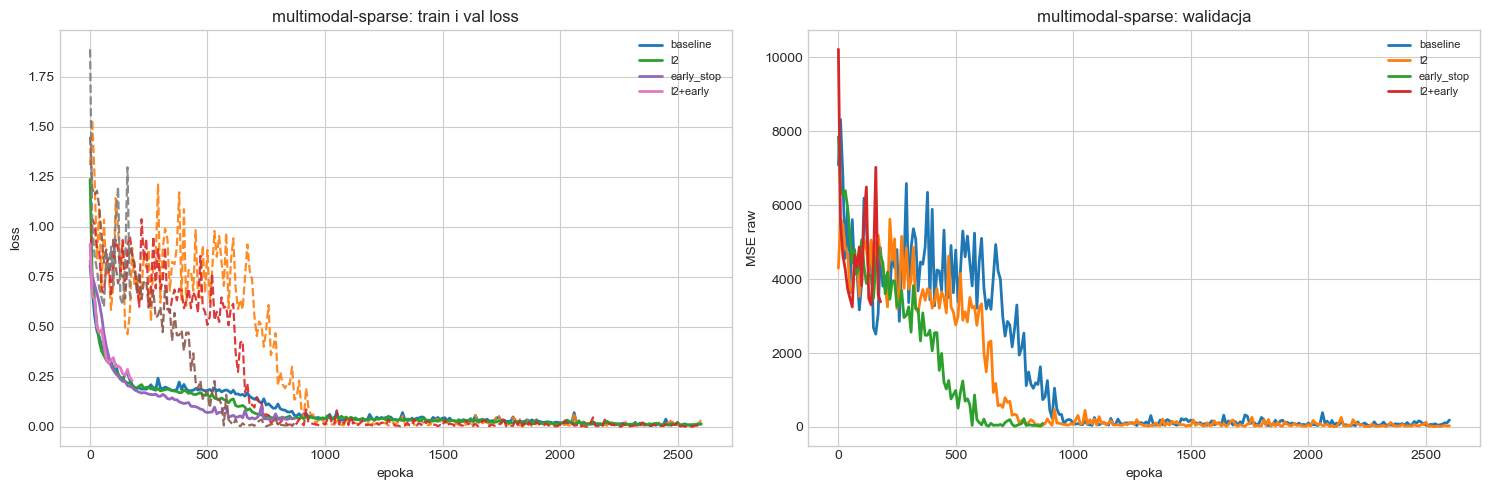

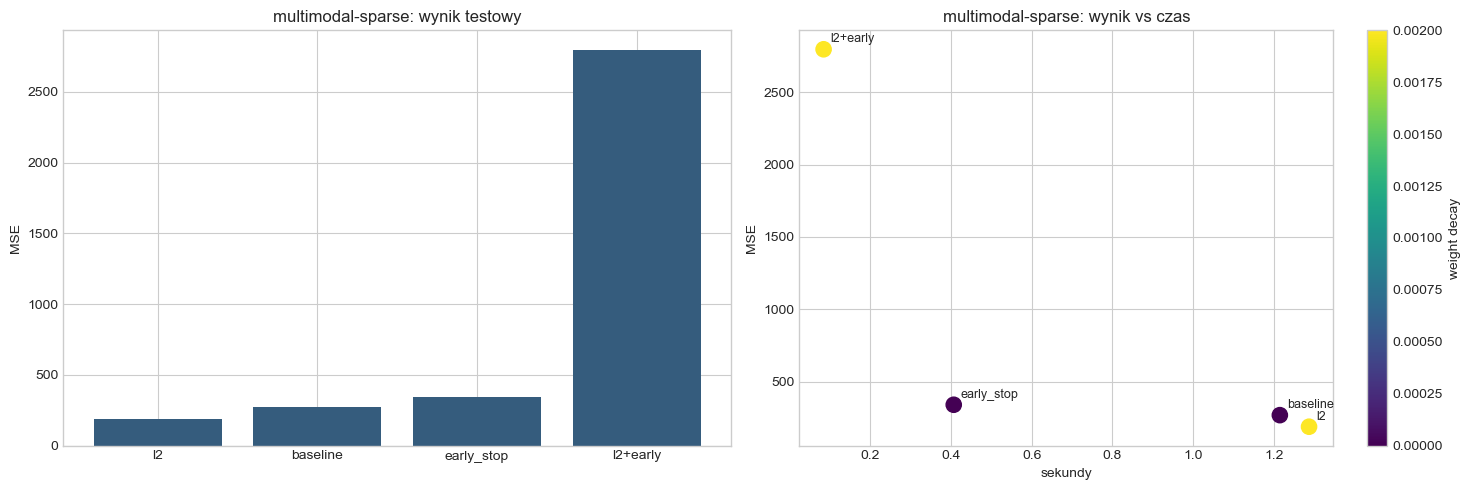

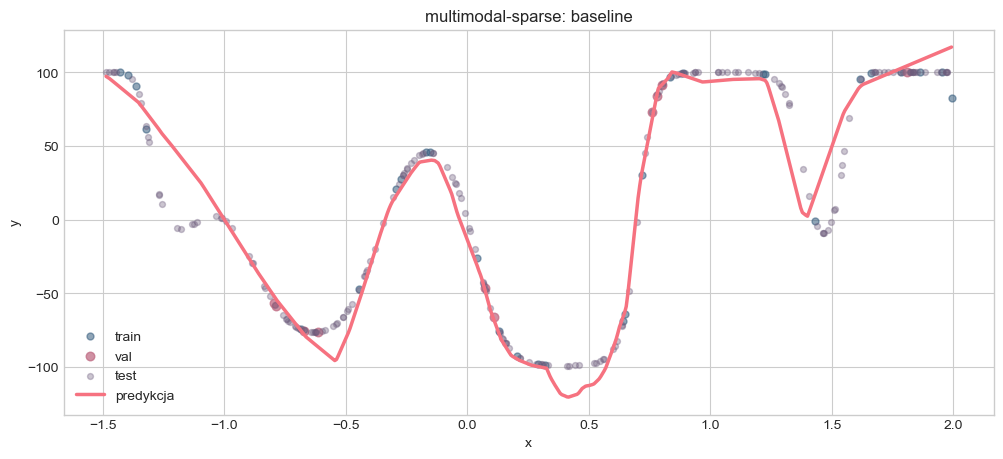

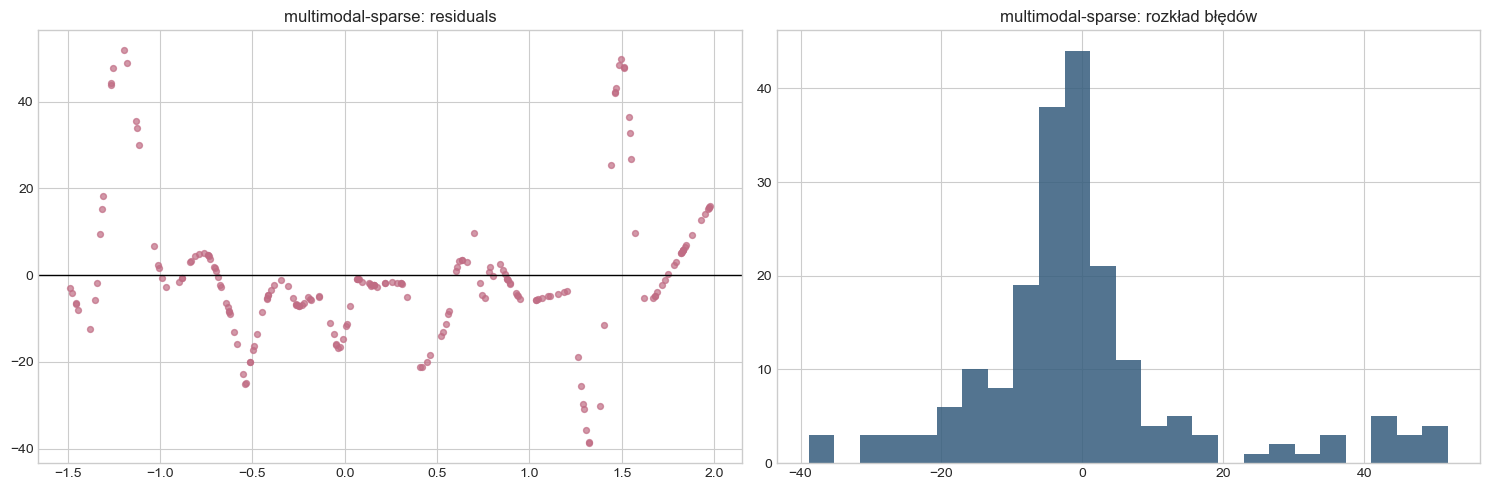

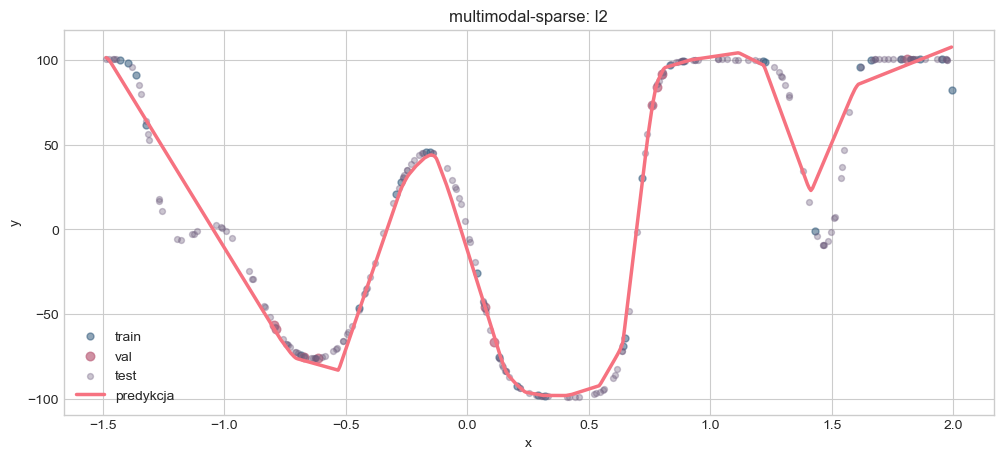

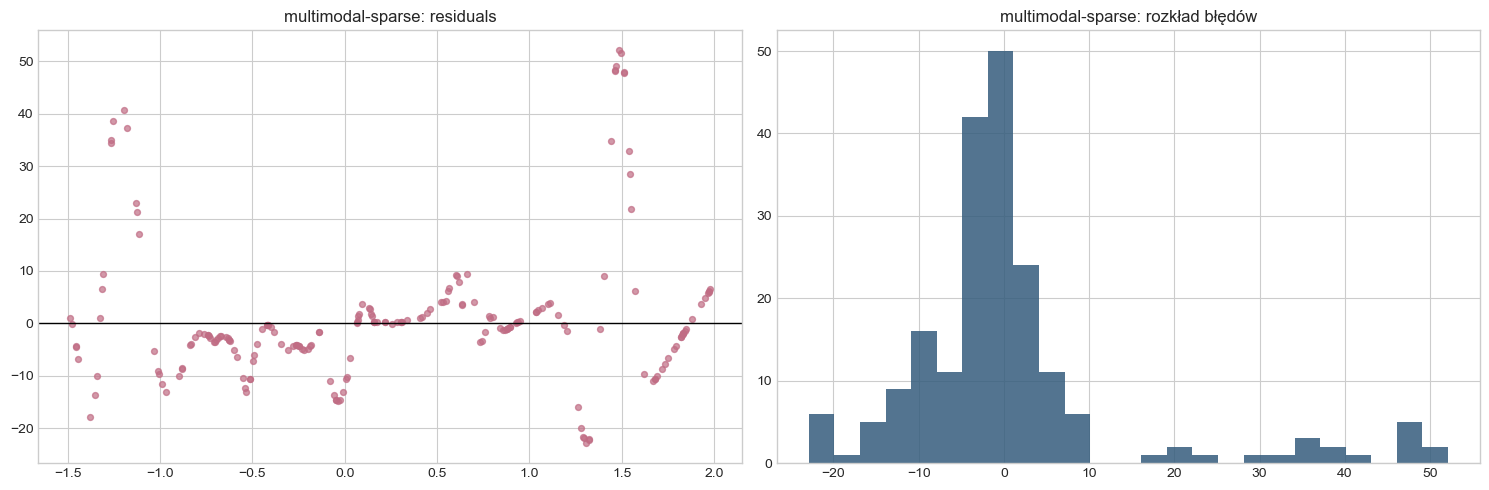

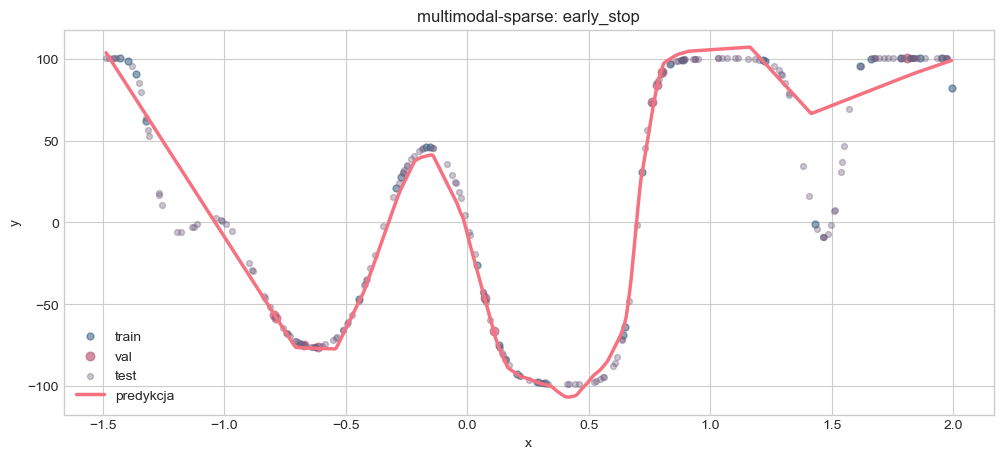

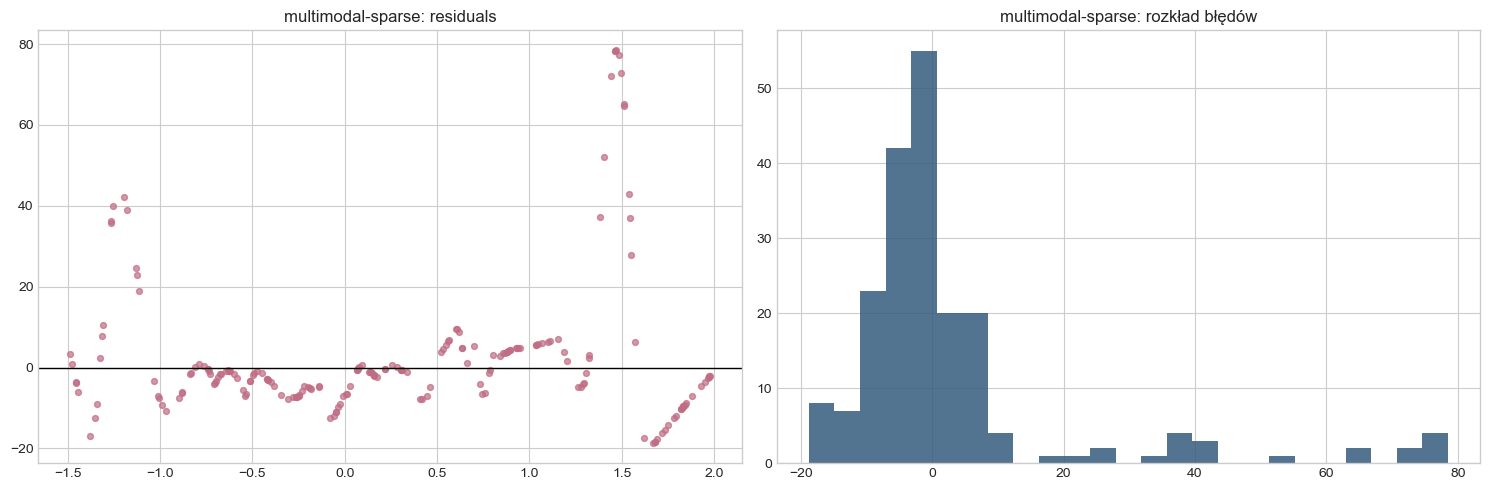

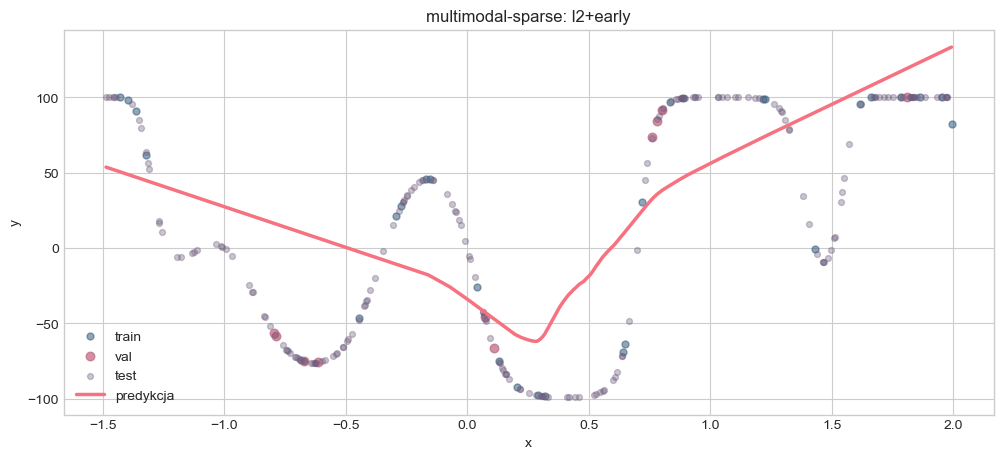

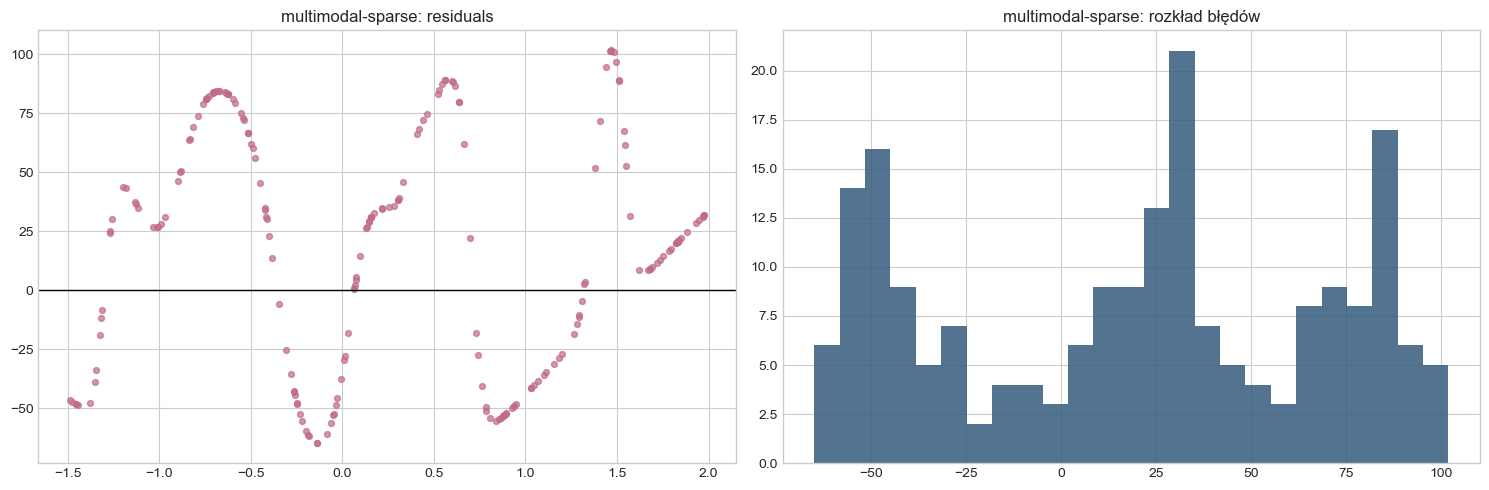

In [5]:
plot_learning_curves(multimodal_results, 'multimodal-sparse', 'regression')
plot_variant_ranking(multimodal_table, 'multimodal-sparse', 'regression')
for run in multimodal_results:
    plot_regression_fit(run)
    plot_regression_residuals(run)

## 3a. komentarz
Na multimodal-sparse najlepszy byl wariant L2: test MSE = 190.245.

Sam early stopping nie pomogl, a L2+early zatrzymal trening zbyt szybko.

Tutaj najwazniejsze bylo ograniczenie zbyt duzych wag.

## 4. rings5-sparse

## 4b. przebieg
Tutaj powtarzam ten sam schemat dla klasyfikacji: screening architektury, a potem porownanie baseline, L2, early stopping i L2+early.

In [6]:
rings5_screen = [
    {'hidden_dims': [32, 16], 'hidden_activation': 'tanh', 'epochs': 2200, 'batch_size': 32, 'lr': 0.0022, 'weight_decay': 0.0, 'early_stopping': False, 'patience': 120, 'decay': 0.92, 'clip_value': 5.0, 'val_ratio': 0.2, 'eval_every': 20},
    {'hidden_dims': [64, 32], 'hidden_activation': 'tanh', 'epochs': 2200, 'batch_size': 32, 'lr': 0.0020, 'weight_decay': 0.0, 'early_stopping': False, 'patience': 120, 'decay': 0.92, 'clip_value': 5.0, 'val_ratio': 0.2, 'eval_every': 20},
    {'hidden_dims': [64, 32, 16], 'hidden_activation': 'relu', 'epochs': 2200, 'batch_size': 32, 'lr': 0.0018, 'weight_decay': 0.0, 'early_stopping': False, 'patience': 120, 'decay': 0.92, 'clip_value': 5.0, 'val_ratio': 0.2, 'eval_every': 20},
]
rings5_screen_results = run_architecture_screen('rings5-sparse', 'classification', rings5_screen)
rings5_screen_table = results_frame(rings5_screen_results)
display(rings5_screen_table)
rings5_best_arch = select_best_architecture(rings5_screen_results)
rings5_base = {
    'hidden_dims': rings5_best_arch['config']['hidden_dims'],
    'hidden_activation': rings5_best_arch['config']['hidden_activation'],
    'epochs': 2600,
    'batch_size': 32,
    'lr': rings5_best_arch['config']['lr'],
    'decay': 0.92,
    'clip_value': 5.0,
    'val_ratio': 0.2,
    'eval_every': 20,
}
rings5_variants = [
    variant_config('baseline', weight_decay=0.0, early_stopping=False, patience=140),
    variant_config('l2', weight_decay=0.0012, early_stopping=False, patience=140),
    variant_config('early_stop', weight_decay=0.0, early_stopping=True, patience=140),
    variant_config('l2+early', weight_decay=0.0012, early_stopping=True, patience=140),
]
rings5_results = run_variant_suite('rings5-sparse', 'classification', rings5_base, rings5_variants)
rings5_table = results_frame(rings5_results)
display(rings5_table)

,dataset,task,variant,hidden_dims,hidden_label,activation,epochs,stopped_epoch,best_epoch,batch_size,lr,weight_decay,early_stopping,params,seconds,val_metric,test_metric
0,rings5-sparse,classification,screen,"(64, 32, 16)",64-32-16,relu,2200,2200,600,32,0.0018,0.0,False,2885,3.162656,0.866498,0.801254
1,rings5-sparse,classification,screen,"(32, 16)",32-16,tanh,2200,2200,720,32,0.0022,0.0,False,709,2.076587,0.876373,0.787708
2,rings5-sparse,classification,screen,"(64, 32)",64-32,tanh,2200,2200,560,32,0.0020,0.0,False,2437,2.678451,0.899444,0.760806


,dataset,task,variant,hidden_dims,hidden_label,activation,epochs,stopped_epoch,best_epoch,batch_size,lr,weight_decay,early_stopping,params,seconds,val_metric,test_metric
0,rings5-sparse,classification,l2,"(64, 32)",64-32,tanh,2600,2600,640,32,0.002,0.0012,False,2437,3.126104,0.872945,0.807781
1,rings5-sparse,classification,baseline,"(64, 32)",64-32,tanh,2600,2600,1120,32,0.002,0.0000,False,2437,3.203696,0.872945,0.801112
2,rings5-sparse,classification,l2+early,"(64, 32)",64-32,tanh,2600,380,240,32,0.002,0.0012,True,2437,0.440509,0.850458,0.752046
3,rings5-sparse,classification,early_stop,"(64, 32)",64-32,tanh,2600,320,180,32,0.002,0.0000,True,2437,0.404927,0.851373,0.663751


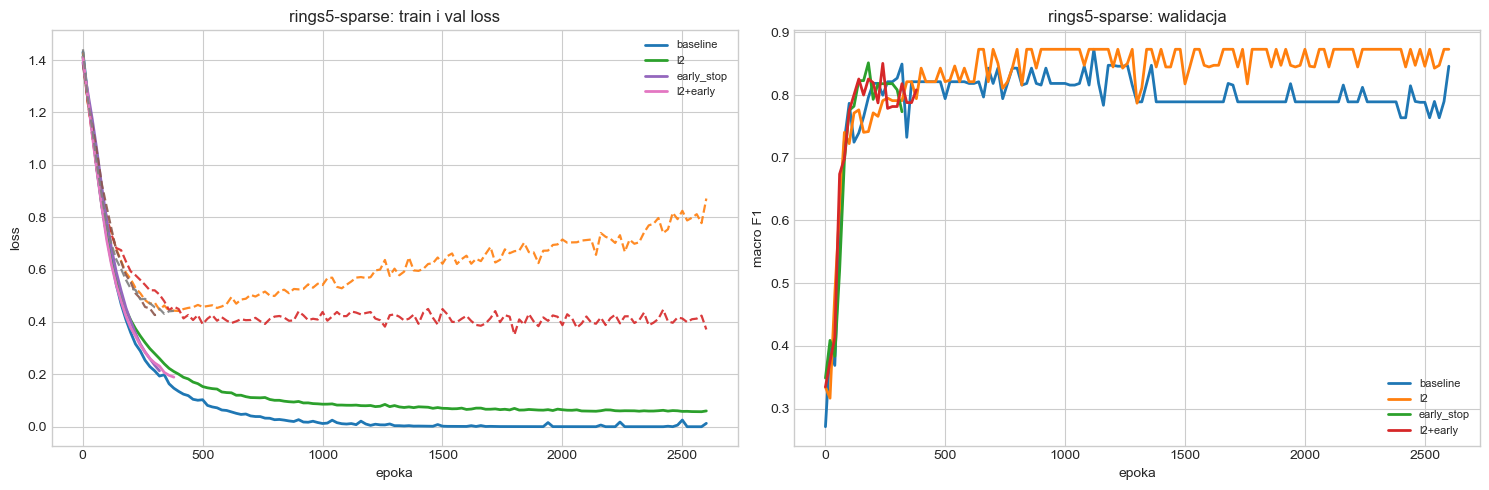

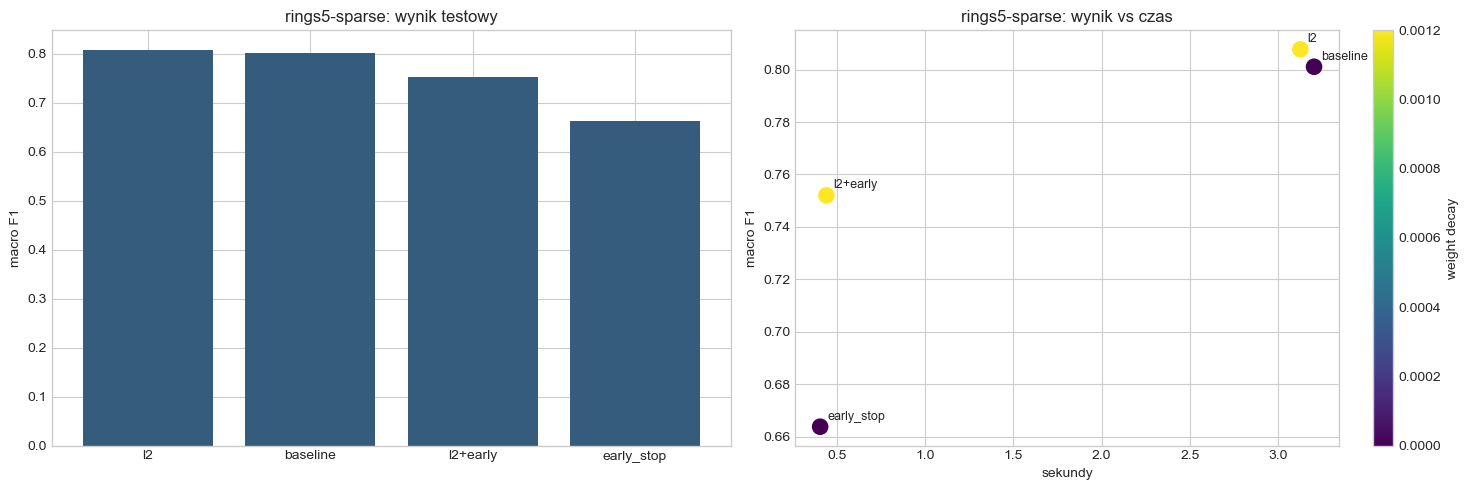

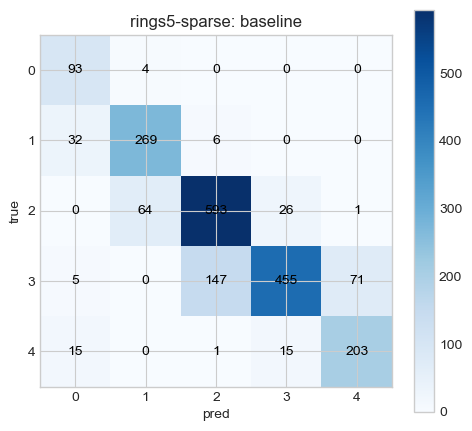

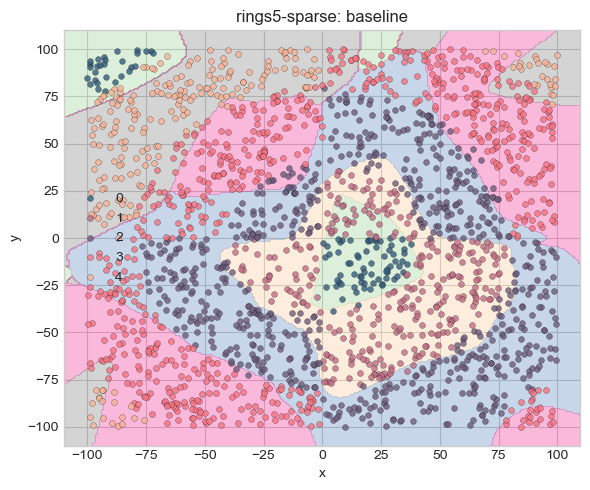

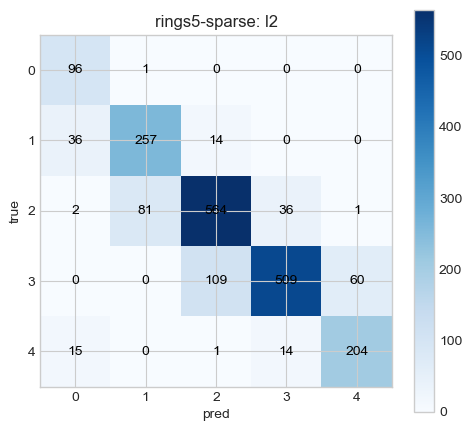

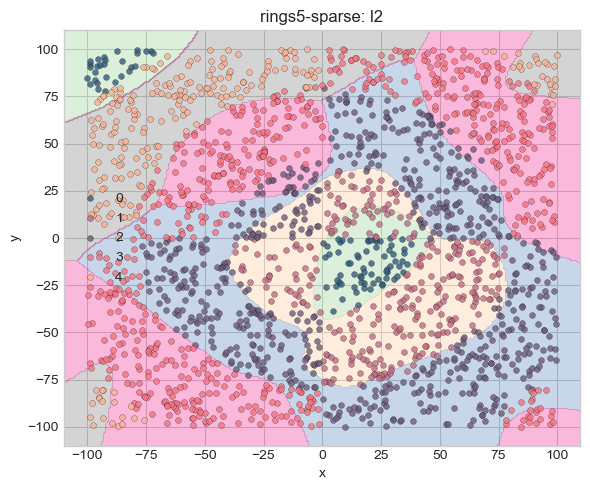

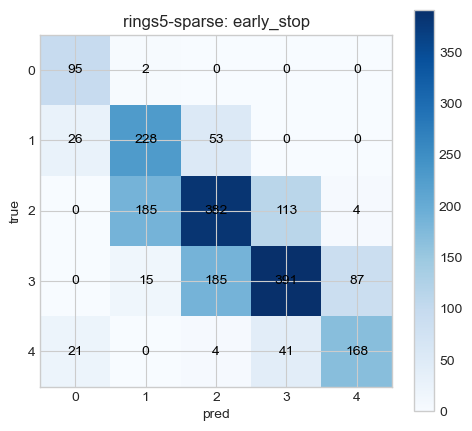

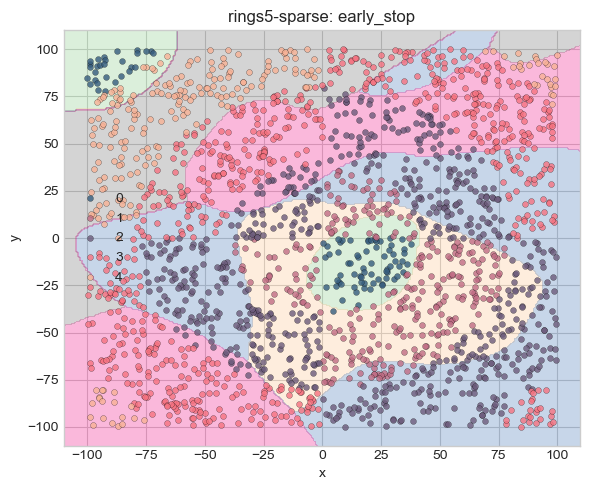

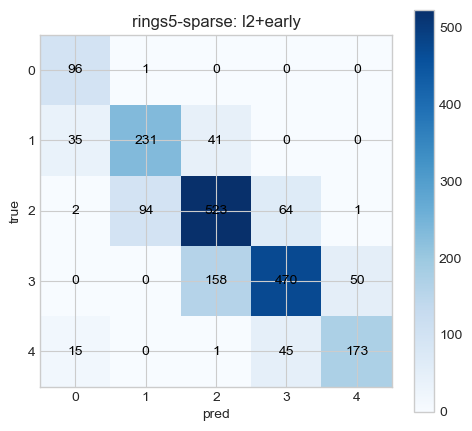

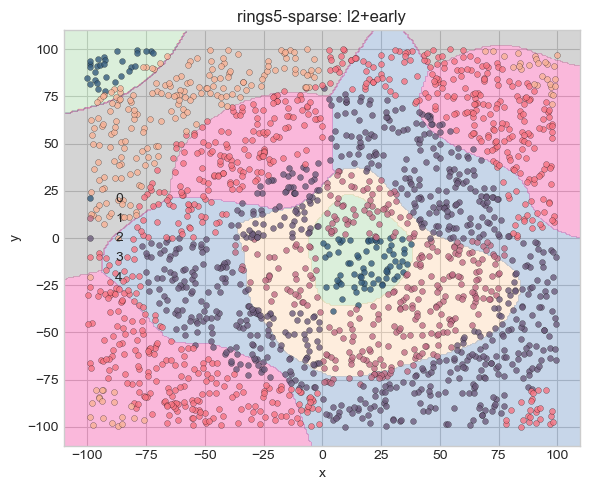

In [7]:
plot_learning_curves(rings5_results, 'rings5-sparse', 'classification')
plot_variant_ranking(rings5_table, 'rings5-sparse', 'classification')
for run in rings5_results:
    plot_confusion(run)
    plot_decision_map(run)

## 4a. komentarz
Na rings5-sparse najlepszy wynik dal wariant L2: macro F1 = 0.808.

Baseline byl bardzo blisko, ale early stopping pogorszyl wynik.

Tutaj lekka regularyzacja pomaga bardziej niz wczesne zatrzymanie.

## 5. rings3-balance

## 5b. przebieg
Na tym zbiorze sprawdzam, czy metody anty-overfittingowe rzeczywiscie pomagaja, czy baza juz sama generalizuje wystarczajaco dobrze.

In [8]:
rings3_screen = [
    {'hidden_dims': [32, 16], 'hidden_activation': 'tanh', 'epochs': 1800, 'batch_size': 64, 'lr': 0.0022, 'weight_decay': 0.0, 'early_stopping': False, 'patience': 120, 'decay': 0.92, 'clip_value': 5.0, 'val_ratio': 0.2, 'eval_every': 20},
    {'hidden_dims': [64, 32, 16], 'hidden_activation': 'tanh', 'epochs': 1800, 'batch_size': 64, 'lr': 0.0020, 'weight_decay': 0.0, 'early_stopping': False, 'patience': 120, 'decay': 0.92, 'clip_value': 5.0, 'val_ratio': 0.2, 'eval_every': 20},
    {'hidden_dims': [64, 32, 16], 'hidden_activation': 'relu', 'epochs': 1800, 'batch_size': 64, 'lr': 0.0018, 'weight_decay': 0.0, 'early_stopping': False, 'patience': 120, 'decay': 0.92, 'clip_value': 5.0, 'val_ratio': 0.2, 'eval_every': 20},
]
rings3_screen_results = run_architecture_screen('rings3-balance', 'classification', rings3_screen)
rings3_screen_table = results_frame(rings3_screen_results)
display(rings3_screen_table)
rings3_best_arch = select_best_architecture(rings3_screen_results)
rings3_base = {
    'hidden_dims': rings3_best_arch['config']['hidden_dims'],
    'hidden_activation': rings3_best_arch['config']['hidden_activation'],
    'epochs': 2200,
    'batch_size': 64,
    'lr': rings3_best_arch['config']['lr'],
    'decay': 0.92,
    'clip_value': 5.0,
    'val_ratio': 0.2,
    'eval_every': 20,
}
rings3_results = run_variant_suite('rings3-balance', 'classification', rings3_base, variant_suite)
rings3_table = results_frame(rings3_results)
display(rings3_table)

,dataset,task,variant,hidden_dims,hidden_label,activation,epochs,stopped_epoch,best_epoch,batch_size,lr,weight_decay,early_stopping,params,seconds,val_metric,test_metric
0,rings3-balance,classification,screen,"(64, 32, 16)",64-32-16,tanh,1800,1800,940,64,0.0020,0.0,False,2851,13.495820,0.937765,0.893572
1,rings3-balance,classification,screen,"(32, 16)",32-16,tanh,1800,1800,780,64,0.0022,0.0,False,675,27.453233,0.952494,0.885432
2,rings3-balance,classification,screen,"(64, 32, 16)",64-32-16,relu,1800,1800,1580,64,0.0018,0.0,False,2851,12.251789,0.963047,0.881940


,dataset,task,variant,hidden_dims,hidden_label,activation,epochs,stopped_epoch,best_epoch,batch_size,lr,weight_decay,early_stopping,params,seconds,val_metric,test_metric
0,rings3-balance,classification,baseline,"(64, 32, 16)",64-32-16,relu,2200,2200,800,64,0.0018,0.0000,False,2851,14.483117,0.954024,0.893748
1,rings3-balance,classification,l2,"(64, 32, 16)",64-32-16,relu,2200,2200,1140,64,0.0018,0.0008,False,2851,14.459481,0.954024,0.891456
2,rings3-balance,classification,l2+early,"(64, 32, 16)",64-32-16,relu,2200,420,300,64,0.0018,0.0008,True,2851,2.718084,0.937782,0.879159
3,rings3-balance,classification,early_stop,"(64, 32, 16)",64-32-16,relu,2200,280,160,64,0.0018,0.0000,True,2851,1.810432,0.939436,0.869463


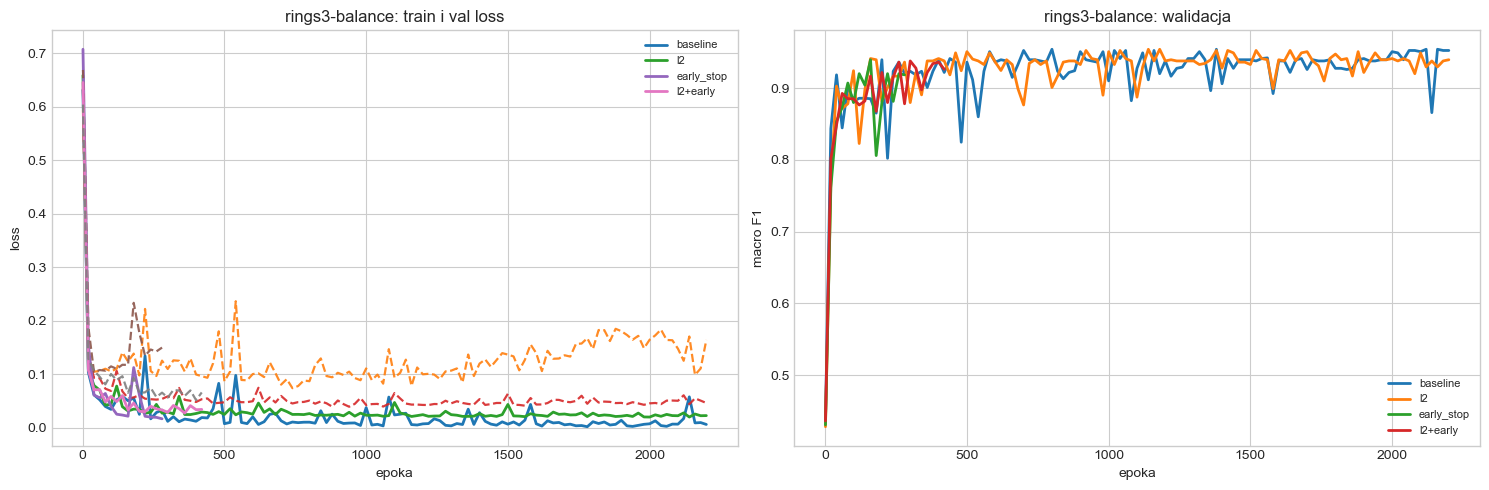

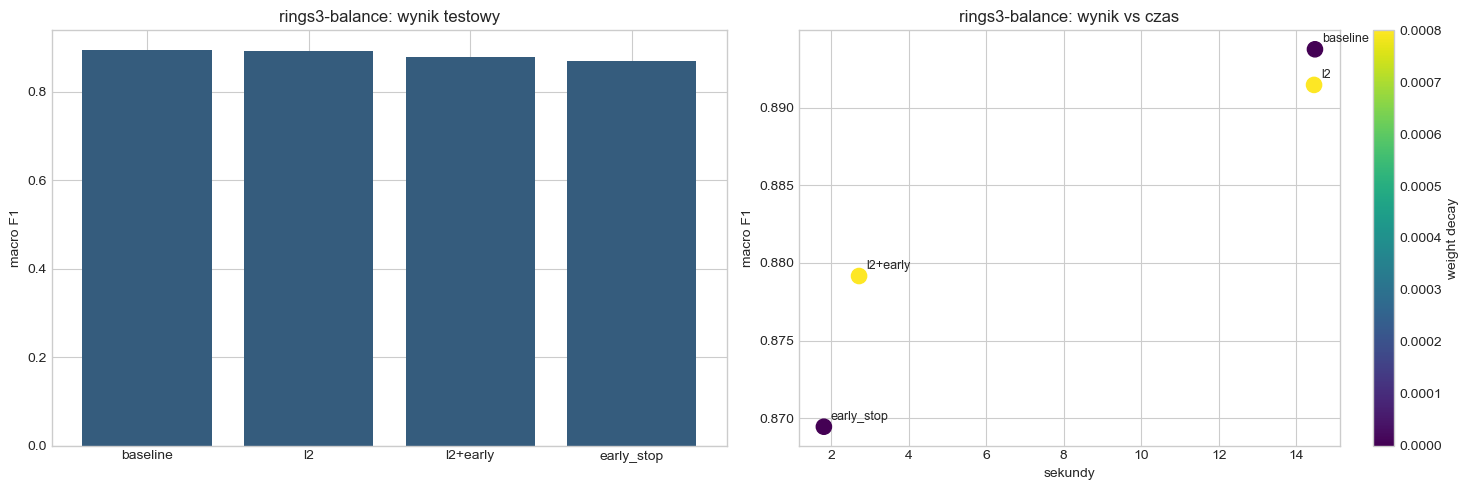

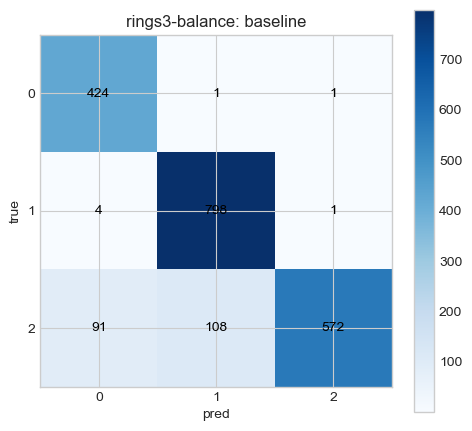

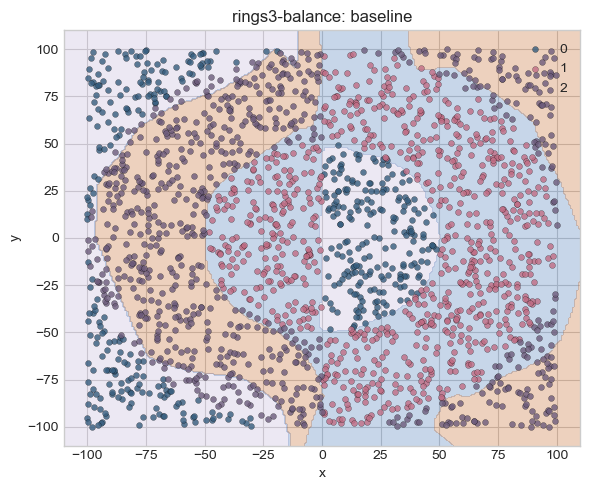

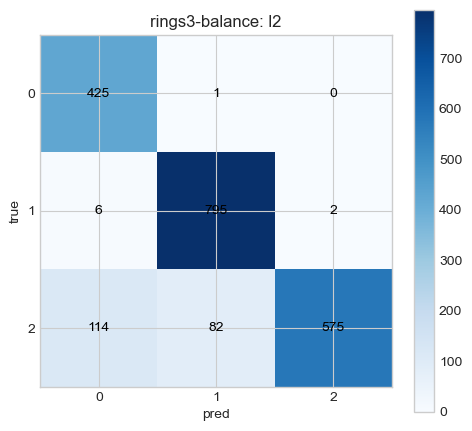

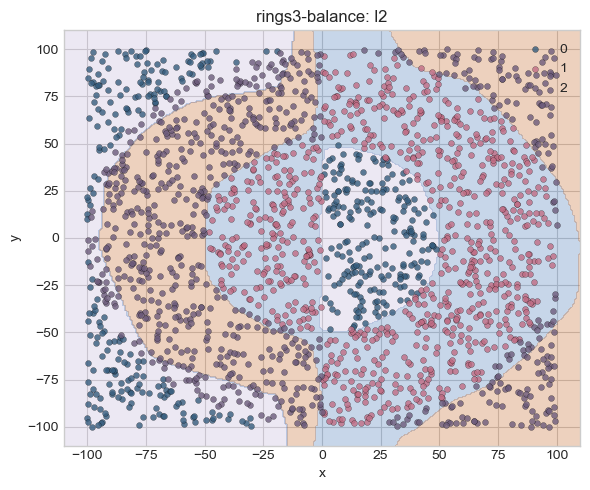

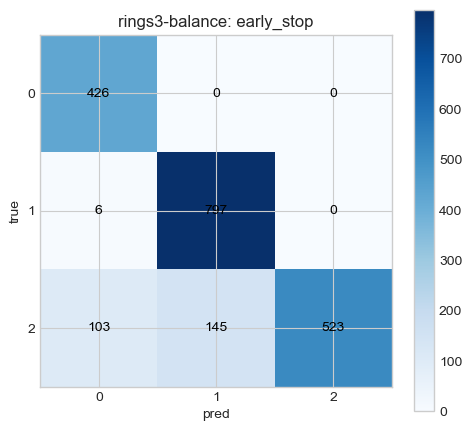

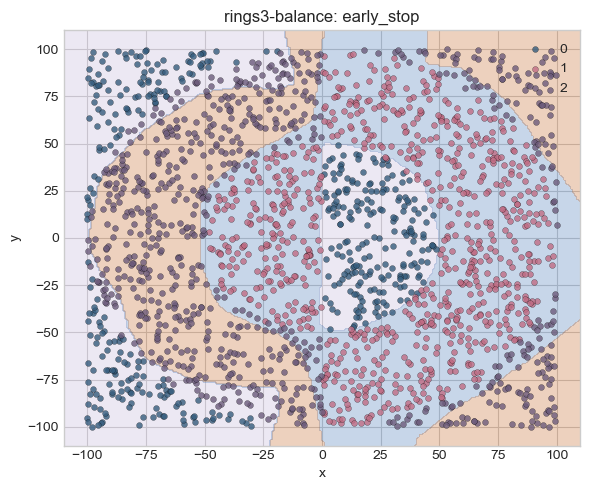

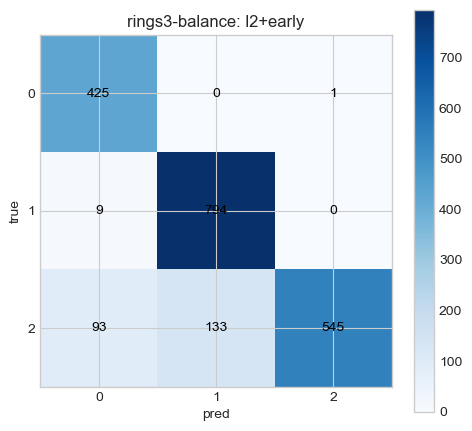

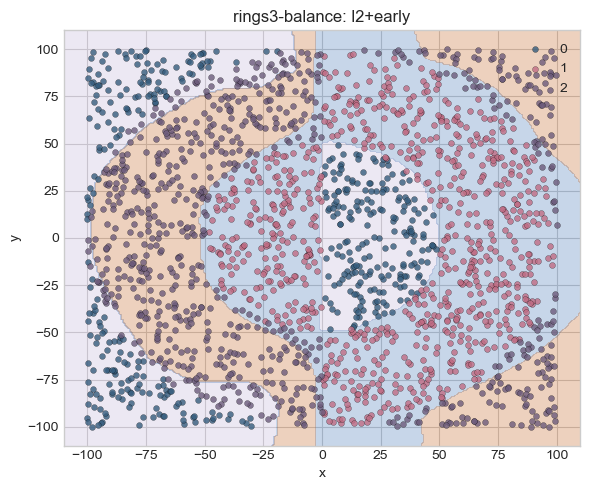

In [9]:
plot_learning_curves(rings3_results, 'rings3-balance', 'classification')
plot_variant_ranking(rings3_table, 'rings3-balance', 'classification')
for run in rings3_results:
    plot_confusion(run)
    plot_decision_map(run)

## 5a. komentarz
Na rings3-balance najlepszy byl baseline: macro F1 = 0.894.

L2 bylo prawie tak samo dobre, a early stopping okazal sie slabszy.

To sugeruje, ze tutaj przeuczenie nie bylo glownym problemem.

## 6. xor3-balance

## 6c. przebieg
Na koncu badam zbior xor3-balance i porownuje te same cztery warianty na wybranej architekturze po screeningu.

In [10]:
xor3_screen = [
    {'hidden_dims': [16, 16], 'hidden_activation': 'tanh', 'epochs': 1800, 'batch_size': 32, 'lr': 0.0025, 'weight_decay': 0.0, 'early_stopping': False, 'patience': 120, 'decay': 0.92, 'clip_value': 5.0, 'val_ratio': 0.2, 'eval_every': 20},
    {'hidden_dims': [32, 16], 'hidden_activation': 'tanh', 'epochs': 1800, 'batch_size': 32, 'lr': 0.0022, 'weight_decay': 0.0, 'early_stopping': False, 'patience': 120, 'decay': 0.92, 'clip_value': 5.0, 'val_ratio': 0.2, 'eval_every': 20},
    {'hidden_dims': [32, 32, 16], 'hidden_activation': 'relu', 'epochs': 1800, 'batch_size': 32, 'lr': 0.0018, 'weight_decay': 0.0, 'early_stopping': False, 'patience': 120, 'decay': 0.92, 'clip_value': 5.0, 'val_ratio': 0.2, 'eval_every': 20},
]
xor3_screen_results = run_architecture_screen('xor3-balance', 'classification', xor3_screen)
xor3_screen_table = results_frame(xor3_screen_results)
display(xor3_screen_table)
xor3_best_arch = select_best_architecture(xor3_screen_results)
xor3_base = {
    'hidden_dims': xor3_best_arch['config']['hidden_dims'],
    'hidden_activation': xor3_best_arch['config']['hidden_activation'],
    'epochs': 2200,
    'batch_size': 32,
    'lr': xor3_best_arch['config']['lr'],
    'decay': 0.92,
    'clip_value': 5.0,
    'val_ratio': 0.2,
    'eval_every': 20,
}
xor3_results = run_variant_suite('xor3-balance', 'classification', xor3_base, variant_suite)
xor3_table = results_frame(xor3_results)
display(xor3_table)

,dataset,task,variant,hidden_dims,hidden_label,activation,epochs,stopped_epoch,best_epoch,batch_size,lr,weight_decay,early_stopping,params,seconds,val_metric,test_metric
0,xor3-balance,classification,screen,"(32, 32, 16)",32-32-16,relu,1800,1800,380,32,0.0018,0.0,False,1714,9.566689,0.974937,0.909570
1,xor3-balance,classification,screen,"(32, 16)",32-16,tanh,1800,1800,360,32,0.0022,0.0,False,658,6.783453,0.972437,0.872360
2,xor3-balance,classification,screen,"(16, 16)",16-16,tanh,1800,1800,1020,32,0.0025,0.0,False,354,6.619221,0.972437,0.868334


,dataset,task,variant,hidden_dims,hidden_label,activation,epochs,stopped_epoch,best_epoch,batch_size,lr,weight_decay,early_stopping,params,seconds,val_metric,test_metric
0,xor3-balance,classification,l2,"(32, 32, 16)",32-32-16,relu,2200,2200,1460,32,0.0018,0.0008,False,1714,11.204635,1.000000,0.891640
1,xor3-balance,classification,baseline,"(32, 32, 16)",32-32-16,relu,2200,2200,120,32,0.0018,0.0000,False,1714,11.482097,0.972437,0.865214
2,xor3-balance,classification,early_stop,"(32, 32, 16)",32-32-16,relu,2200,360,240,32,0.0018,0.0000,True,1714,1.821035,0.972437,0.845538
3,xor3-balance,classification,l2+early,"(32, 32, 16)",32-32-16,relu,2200,360,240,32,0.0018,0.0008,True,1714,1.817210,0.947500,0.828159


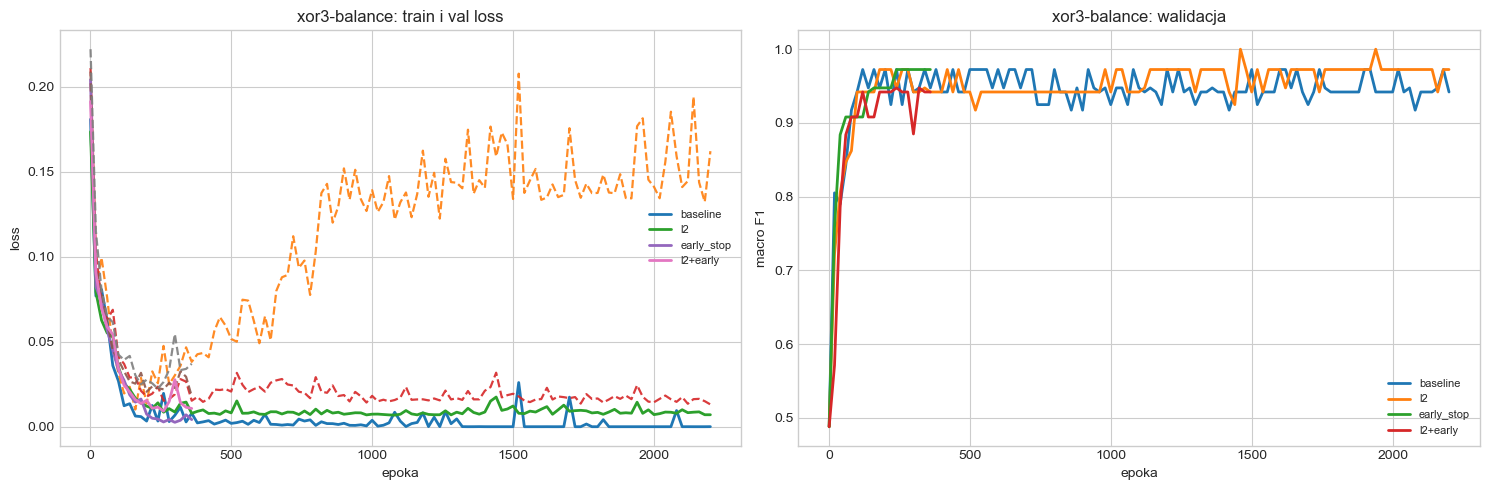

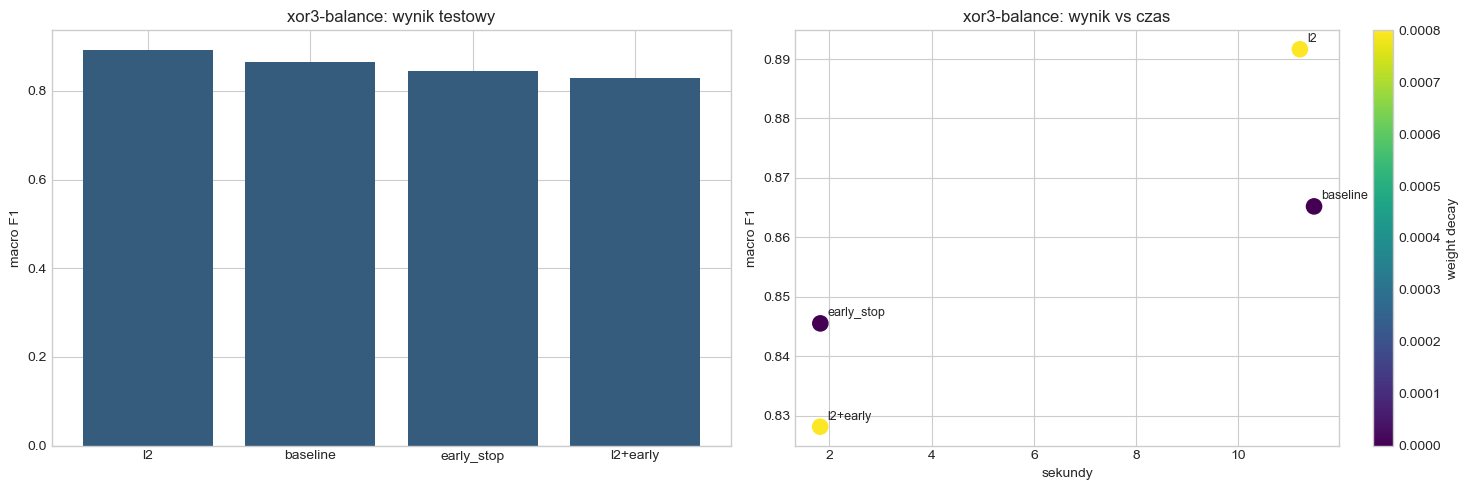

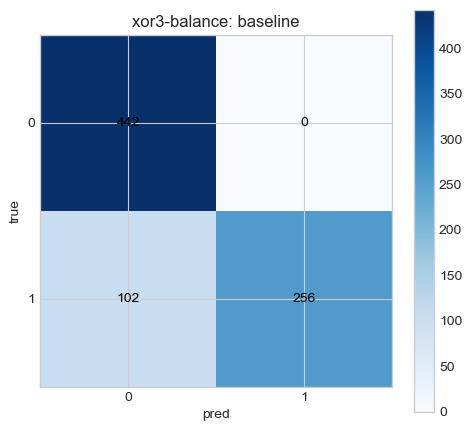

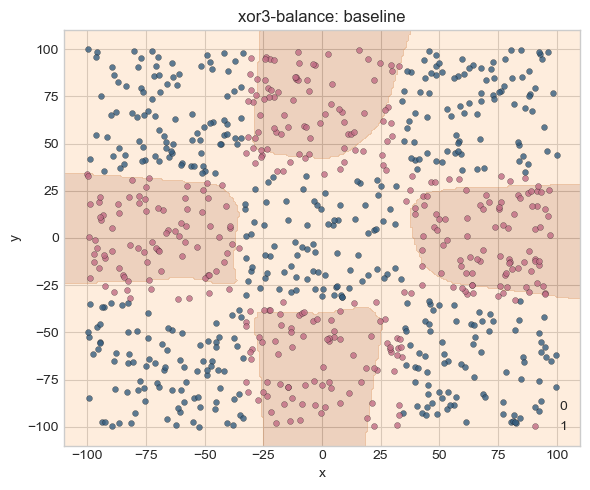

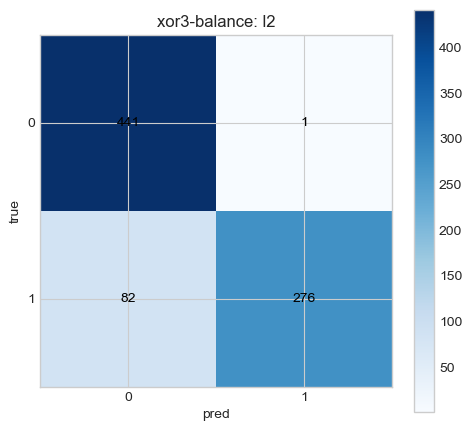

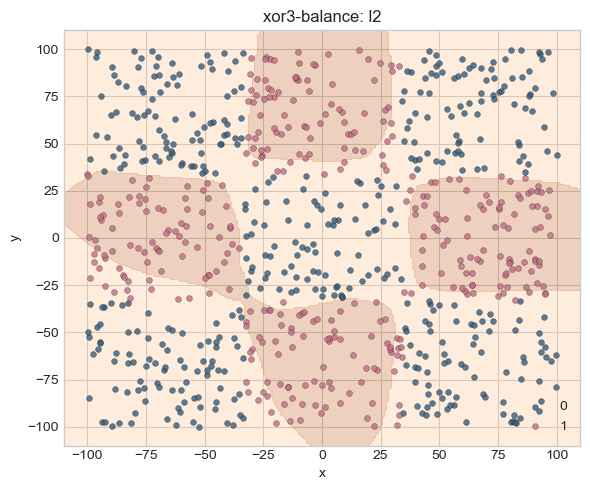

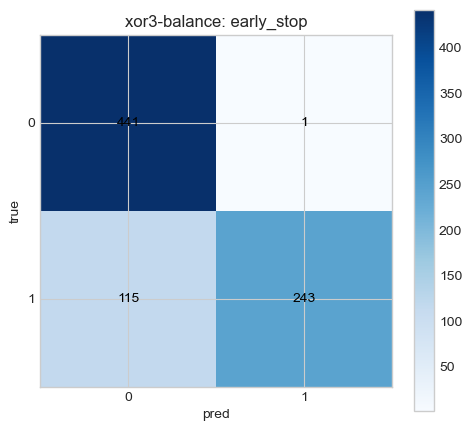

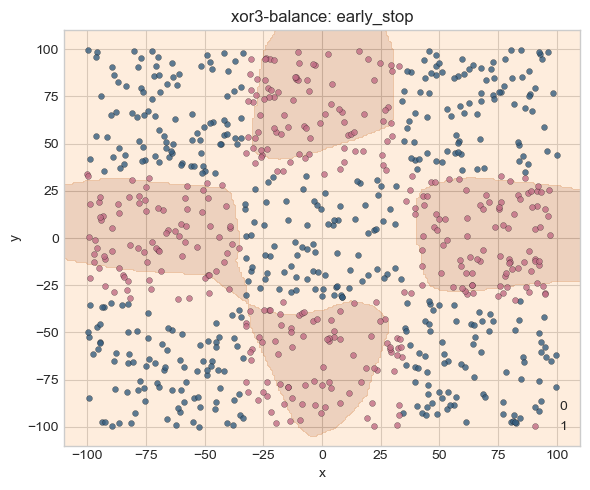

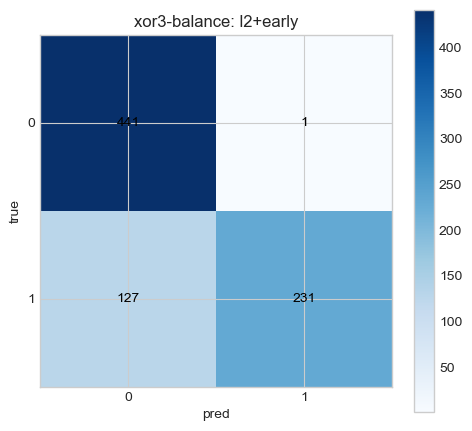

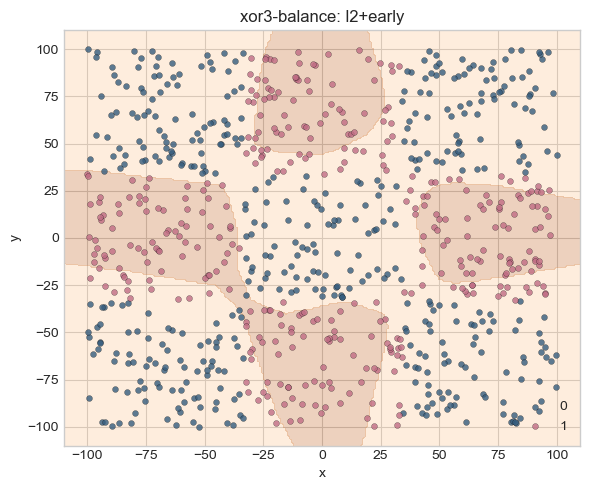

In [11]:
plot_learning_curves(xor3_results, 'xor3-balance', 'classification')
plot_variant_ranking(xor3_table, 'xor3-balance', 'classification')
for run in xor3_results:
    plot_confusion(run)
    plot_decision_map(run)

## 6a. komentarz
Na xor3-balance najlepszy byl wariant L2: macro F1 = 0.892.

Early stopping oraz L2+early byly slabsze, bo zatrzymywaly trening zbyt szybko.

W tym zbiorze regularyzacja wag pomogla, ale model musial dostac odpowiednio duzo epok.

In [ ]:
from pathlib import Path
import contextlib
import matplotlib.pyplot as plt

outputs_dir = Path('c:/Users/olobr/OneDrive/Pulpit/mio/mio6/outputs')
outputs_dir.mkdir(parents=True, exist_ok=True)

def save_df(name, df):
    (outputs_dir / f'{name}.txt').write_text(df.to_string(index=False), encoding='utf-8')
    df.to_html(outputs_dir / f'{name}.html', index=False)

save_df('cell_004_preview_multimodal_sparse', preview_dataset('multimodal-sparse', 'regression'))
save_df('cell_004_preview_rings5_sparse', preview_dataset('rings5-sparse', 'classification'))
save_df('cell_004_preview_rings3_balance', preview_dataset('rings3-balance', 'classification'))
save_df('cell_004_preview_xor3_balance', preview_dataset('xor3-balance', 'classification'))

save_df('cell_008_multimodal_screen_table', multimodal_screen_table)
save_df('cell_008_multimodal_table', multimodal_table)
save_df('cell_011_rings5_screen_table', rings5_screen_table)
save_df('cell_011_rings5_table', rings5_table)
save_df('cell_014_rings3_screen_table', rings3_screen_table)
save_df('cell_014_rings3_table', rings3_table)
save_df('cell_017_xor3_screen_table', xor3_screen_table)
save_df('cell_017_xor3_table', xor3_table)

original_show = plt.show
plot_counter = {'i': 0}

def export_show(*args, **kwargs):
    fig = plt.gcf()
    if fig is not None and fig.number is not None:
        plot_counter['i'] += 1
        fig.savefig(outputs_dir / f"plot_{plot_counter['i']:03d}.png", dpi=160, bbox_inches='tight')
    return original_show(*args, **kwargs)

@contextlib.contextmanager
def capture_plots():
    plt.show = export_show
    try:
        yield
    finally:
        plt.show = original_show

with capture_plots():
    plot_learning_curves(multimodal_results, 'multimodal-sparse', 'regression')
    plot_variant_ranking(multimodal_table, 'multimodal-sparse', 'regression')
    for run in multimodal_results:
        plot_regression_fit(run)
        plot_regression_residuals(run)

    plot_learning_curves(rings5_results, 'rings5-sparse', 'classification')
    plot_variant_ranking(rings5_table, 'rings5-sparse', 'classification')
    for run in rings5_results:
        plot_confusion(run)
        plot_decision_map(run)

    plot_learning_curves(rings3_results, 'rings3-balance', 'classification')
    plot_variant_ranking(rings3_table, 'rings3-balance', 'classification')
    for run in rings3_results:
        plot_confusion(run)
        plot_decision_map(run)

    plot_learning_curves(xor3_results, 'xor3-balance', 'classification')
    plot_variant_ranking(xor3_table, 'xor3-balance', 'classification')
    for run in xor3_results:
        plot_confusion(run)
        plot_decision_map(run)

if 'my_table' in globals():
    save_df('cell_020_my_table', my_table)

print(f'Eksport zakonczony. Zapisane pliki: {len(list(outputs_dir.glob("*")))} w {outputs_dir}')

## 6b. wniosek
Najbardziej uniwersalnie pomogla regularyzacja L2: wygrala na trzech z czterech zbiorow.

Early stopping nie byl tutaj tak stabilny i czesto ucinal trening zbyt wczesnie.

Koncowy wniosek: sama regularyzacja wag okazala sie bardziej niezawodna niz wczesne zatrzymanie.

## 7. momentum


## 7a. przebieg
Na koncu porownuje jeszcze optimizer Momentum. Nie robie nowego screeningu: biore najlepsze architektury znalezione wczesniej i sprawdzam tylko, jak zmienia sie zachowanie regularyzacji oraz early stopping.


## 7b. regresja
Najpierw sprawdzam `multimodal-sparse`, bo to najbardziej czytelny zbior do oceny zbieznosci i overfittingu w regresji.


In [ ]:
momentum_multimodal_base = {
    'hidden_dims': multimodal_best_arch['config']['hidden_dims'],
    'hidden_activation': multimodal_best_arch['config']['hidden_activation'],
    'epochs': 2600,
    'batch_size': 16,
    'lr': 0.006,
    'momentum': 0.9,
    'optimizer_name': 'momentum',
    'decay': 0.92,
    'clip_value': 5.0,
    'val_ratio': 0.25,
    'eval_every': 10,
}
momentum_multimodal_variants = [
    variant_config('baseline', weight_decay=0.0, early_stopping=False, patience=140),
    variant_config('l2', weight_decay=0.0012, early_stopping=False, patience=140),
    variant_config('early_stop', weight_decay=0.0, early_stopping=True, patience=140),
    variant_config('l2+early', weight_decay=0.0012, early_stopping=True, patience=140),
]
momentum_multimodal_results = run_variant_suite('multimodal-sparse', 'regression', momentum_multimodal_base, momentum_multimodal_variants)
momentum_multimodal_table = results_frame(momentum_multimodal_results)
display(momentum_multimodal_table)


In [ ]:
plot_learning_curves(momentum_multimodal_results, 'multimodal-sparse / momentum', 'regression')
plot_variant_ranking(momentum_multimodal_table, 'multimodal-sparse / momentum', 'regression')
for run in momentum_multimodal_results:
    plot_regression_fit(run)
    plot_regression_residuals(run)


## 7c. klasyfikacja
Potem sprawdzam `rings5-sparse`, bo to trudniejszy przypadek klasyfikacyjny i dobrze pokazuje, czy Momentum utrzyma granice decyzyjne bez nowego strojenia architektury.


In [ ]:
momentum_rings5_base = {
    'hidden_dims': rings5_best_arch['config']['hidden_dims'],
    'hidden_activation': rings5_best_arch['config']['hidden_activation'],
    'epochs': 2600,
    'batch_size': 32,
    'lr': 0.01,
    'momentum': 0.9,
    'optimizer_name': 'momentum',
    'decay': 0.92,
    'clip_value': 5.0,
    'val_ratio': 0.2,
    'eval_every': 20,
}
momentum_rings5_variants = [
    variant_config('baseline', weight_decay=0.0, early_stopping=False, patience=160),
    variant_config('l2', weight_decay=0.0012, early_stopping=False, patience=160),
    variant_config('early_stop', weight_decay=0.0, early_stopping=True, patience=160),
    variant_config('l2+early', weight_decay=0.0012, early_stopping=True, patience=160),
]
momentum_rings5_results = run_variant_suite('rings5-sparse', 'classification', momentum_rings5_base, momentum_rings5_variants)
momentum_rings5_table = results_frame(momentum_rings5_results)
display(momentum_rings5_table)


In [ ]:
plot_learning_curves(momentum_rings5_results, 'rings5-sparse / momentum', 'classification')
plot_variant_ranking(momentum_rings5_table, 'rings5-sparse / momentum', 'classification')
for run in momentum_rings5_results:
    plot_confusion(run)
    plot_decision_map(run)


## 7d. komentarz
To jest tylko dodatek porownawczy. Dzieki niemu mozna sprawdzic, czy przy tej samej architekturze i podobnym poziomie regularyzacji Momentum daje podobne albo slabsze wnioski niz RMSProp.
